# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/girishpatil935/ML_Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Action ranking approach

The action queue combines the transparent Week-4 baseline opportunity score with the descriptive Week-5 content-performance archetypes.

The baseline score ranks pages where observed CTR is below the typical CTR for their search-position tier, with an impressions threshold of 500. This provides the primary ranking signal because it directly identifies pages with measurable search visibility and a potential CTR review opportunity.

The Week-5 K-Means cluster is used as context rather than as a prediction target. The three clusters describe different observed performance patterns:

- **Cluster 0 — Low-visibility, unstable pages:** low visibility, weak observed ranking, and higher position volatility.
- **Cluster 1 — High-visibility performance pages:** substantially higher visibility, stronger median CTR, relatively strong ranking, and low volatility.
- **Cluster 2 — Low-visibility, relatively well-ranked pages:** low observed visibility despite relatively strong median average position.

Each queue item receives a reason code and a suggested review action. These are decision-support recommendations, not automated content decisions.

The queue is ranked by the Week-4 baseline opportunity score. Cluster membership provides additional context for human review.

In [2]:
# =========================================================
# ML-10 — Build the ranked action queue
# =========================================================

import os
import getpass
import duckdb
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans


# ---------------------------------------------------------
# 1. Connect to the March 2026 warehouse slice
# ---------------------------------------------------------

def get_hf_token():
    token = os.environ.get("HF_TOKEN")

    if token:
        return token

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")

        if token:
            return token
    except Exception:
        pass

    return getpass.getpass(
        "Paste your Hugging Face READ token (hf_...): "
    )


HF_TOKEN = get_hf_token()

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf
(TYPE huggingface, TOKEN '{HF_TOKEN}')
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)


# ---------------------------------------------------------
# 2. Recreate the Week-5 feature vector
# ---------------------------------------------------------

feature_vector = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,

        SUM(gsc_clicks) AS clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks)
                 / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr,

        AVG(
            NULLIF(gsc_avg_position, 0)
        ) AS avg_position,

        STDDEV_SAMP(
            NULLIF(gsc_avg_position, 0)
        ) AS position_volatility

    FROM {FACT_DAILY}

    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Feature vector rows:", len(feature_vector))
print("Clients:", feature_vector["client_hash_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature vector rows: 176738
Clients: 47


In [3]:
# ---------------------------------------------------------
# 3. Recreate the Week-4 baseline opportunity score
# ---------------------------------------------------------

baseline_df = feature_vector.copy()

# Position buckets used by the Week-4 baseline
def position_bucket(position):
    if pd.isna(position):
        return "unknown"
    elif position <= 3:
        return "1-3"
    elif position <= 10:
        return "4-10"
    elif position <= 20:
        return "11-20"
    else:
        return "20+"


baseline_df["position_bucket"] = (
    baseline_df["avg_position"].apply(position_bucket)
)

# Expected CTR by position tier
expected_ctr = (
    baseline_df[
        baseline_df["position_bucket"] != "unknown"
    ]
    .groupby("position_bucket")["ctr"]
    .median()
)

baseline_df["expected_ctr"] = (
    baseline_df["position_bucket"]
    .map(expected_ctr)
)

baseline_df["ctr_gap"] = (
    baseline_df["expected_ctr"] -
    baseline_df["ctr"]
).clip(lower=0)

# Same Week-4 visibility threshold
baseline_df["baseline_action_score"] = np.where(
    baseline_df["impressions"] >= 500,
    np.log1p(baseline_df["impressions"])
    * baseline_df["ctr_gap"],
    0
)

baseline_df["reason_code"] = np.where(
    baseline_df["baseline_action_score"] > 0,
    "high_visibility_low_ctr",
    "no_baseline_opportunity"
)

print(
    "Pages with baseline opportunity:",
    (baseline_df["baseline_action_score"] > 0).sum()
)

print(
    "Highest baseline score:",
    baseline_df["baseline_action_score"].max()
)

Pages with baseline opportunity: 1368
Highest baseline score: 0.9872026178035626


In [4]:
# ---------------------------------------------------------
# 4. Recreate the validated K=3 archetypes
# ---------------------------------------------------------

cluster_features = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "position_volatility"
]

X_cluster = baseline_df[cluster_features].copy()

# Same transformations used in Week 5
X_cluster["impressions"] = np.log1p(
    X_cluster["impressions"]
)

X_cluster["clicks"] = np.log1p(
    X_cluster["clicks"]
)

cluster_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

X_cluster_scaled = cluster_preprocessor.fit_transform(
    X_cluster
)

final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

baseline_df["cluster"] = (
    final_kmeans.fit_predict(X_cluster_scaled)
)

cluster_action_map = {
    0: {
        "archetype": "Low-visibility, unstable pages",
        "action": "Investigate visibility and content quality"
    },
    1: {
        "archetype": "High-visibility performance pages",
        "action": "Review CTR opportunity and protect performance"
    },
    2: {
        "archetype": "Low-visibility, relatively well-ranked pages",
        "action": "Investigate visibility and search demand"
    }
}

baseline_df["archetype"] = (
    baseline_df["cluster"]
    .map(lambda x: cluster_action_map[x]["archetype"])
)

baseline_df["suggested_action"] = (
    baseline_df["cluster"]
    .map(lambda x: cluster_action_map[x]["action"])
)

print(
    baseline_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    92633
1    36513
2    47592
Name: count, dtype: int64


In [5]:
# ---------------------------------------------------------
# 5. Create the ranked human-review queue
# ---------------------------------------------------------

action_queue = (
    baseline_df[
        baseline_df["baseline_action_score"] > 0
    ]
    .copy()
)

action_queue["review_priority"] = (
    action_queue["baseline_action_score"]
)

action_queue = action_queue.sort_values(
    "review_priority",
    ascending=False
).reset_index(drop=True)

action_queue["rank"] = (
    np.arange(len(action_queue)) + 1
)

action_queue = action_queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "review_priority",
        "reason_code",
        "cluster",
        "archetype",
        "suggested_action",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "position_volatility"
    ]
]

print("Ranked queue rows:", len(action_queue))

display(
    action_queue.head(20)
)

Ranked queue rows: 1368


,rank,client_hash_id,content_hash_id,review_priority,reason_code,cluster,archetype,suggested_action,impressions,clicks,ctr,avg_position,position_volatility
0,1,client_1a730cb2640a1abf,content_d61fc394d10cba41,0.987203,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,38000.0,1.0,0.002632,2.740744,2.044146
1,2,client_fef1a8f436438636,content_66bf45eb0c5bb550,0.930140,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,24259.0,1.0,0.004122,2.784944,1.506762
2,3,client_a80fca3f171ed1de,content_fa17add7836d36c3,0.908622,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,12588.0,0.0,0.000000,1.902457,1.579138
3,4,client_73cda7b4e4f265ea,content_d397987113cb84a0,0.885378,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,9887.0,0.0,0.000000,1.953104,0.441814
4,5,client_23a62021009f63c4,content_a27b382f00aa75c6,0.861768,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,7736.0,0.0,0.000000,2.259812,2.027308
5,6,client_73cda7b4e4f265ea,content_b9acd1ebff7d34ff,0.860672,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,25941.0,3.0,0.011565,2.418270,0.900653
6,7,client_e547b89c05043229,content_83167156f76e33e5,0.849739,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,6827.0,0.0,0.000000,1.136714,0.651147
7,8,client_fef1a8f436438636,content_1bc8782404e3b132,0.833918,high_visibility_low_ctr,0,"Low-visibility, unstable pages",Investigate visibility and content quality,5792.0,0.0,0.000000,2.339752,1.622473
8,9,client_20259bd6705d81d4,content_9cec93fc44a7ab41,0.814670,high_visibility_low_ctr,0,"Low-visibility, unstable pages",Investigate visibility and content quality,4742.0,0.0,0.000000,1.852298,1.593465
9,10,client_20259bd6705d81d4,content_35ddcd760c64da18,0.812444,high_visibility_low_ctr,2,"Low-visibility, relatively well-ranked pages",Investigate visibility and search demand,11090.0,1.0,0.009017,0.989128,1.579008


### Intended use

This playbook is intended to support human review of content-performance opportunities.

It can be used by content and SEO teams to:

- Prioritize pages with observed search visibility and a potential CTR improvement opportunity.
- Use content-performance archetypes as context when reviewing individual pages.
- Identify pages that may need deeper investigation of visibility, ranking, search demand, or content quality.
- Provide a consistent, evidence-based starting point for content review.

The ranked queue is a prioritization aid, not an automated content decision system.

### What this playbook does not establish

The analysis does not establish that:

- A low CTR is caused by the page title, meta description, or content quality.
- A cluster represents a true business or content category.
- A page should be rewritten, merged, refreshed, or removed solely because of its cluster or score.
- Observed performance differences are causal.
- The model captures query intent, SERP features, seasonality, business value, cannibalization, indexing issues, or page quality.
- The clustering model predicts future page performance.

The March 2026 data is used as a fixed development window. The resulting queue should therefore be treated as a review snapshot rather than a permanent ranking.

### Limits

Before taking action, reviewers should validate:

1. **Search intent** — whether the page matches the queries it is appearing for.
2. **SERP context** — competing results, SERP features, and search-result presentation.
3. **Business value** — whether the page supports an important business or user objective.
4. **Technical status** — indexing, availability, redirects, canonicalization, and other technical conditions.
5. **Content context** — quality, freshness, completeness, and relevance.
6. **Historical context** — seasonality, recent changes, and refresh history.
7. **Cannibalization** — whether another page is competing for similar search demand.

A queue item should be considered a prompt for investigation, not proof that an action is required.

In [6]:
print("### Action queue summary")

print("Total ranked actions:", len(action_queue))
print(
    "Unique clients:",
    action_queue["client_hash_id"].nunique()
)
print(
    "Median review priority:",
    round(action_queue["review_priority"].median(), 4)
)

print("\nReason codes:")
display(
    action_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

print("\nArchetypes:")
display(
    action_queue["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="count")
)

### Action queue summary
Total ranked actions: 1368
Unique clients: 19
Median review priority: 0.5392

Reason codes:


,reason_code,count
0,high_visibility_low_ctr,1368



Archetypes:


,archetype,count
0,"Low-visibility, relatively well-ranked pages",733
1,"Low-visibility, unstable pages",635


### Human review rules

Every ranked action must be reviewed by a person before any content change is made.

For each candidate, the reviewer should:

1. Check the search queries and search intent associated with the page.
2. Review the current SERP context and competing results.
3. Verify that the page is indexed, accessible, canonicalized correctly, and technically healthy.
4. Check whether recent updates, seasonality, or other historical changes could explain the observed performance.
5. Evaluate content quality, relevance, freshness, and completeness.
6. Check for possible keyword cannibalization with other pages.
7. Consider the business or user value of the page before deciding on an action.
8. Record the evidence supporting the final action.

The queue score determines review priority, not the final action.

### No-go list: actions that should not be automated

The following decisions should not be automated from this analysis:

- Automatically rewriting page titles or meta descriptions.
- Automatically rewriting or generating page content.
- Automatically deleting or pruning pages.
- Automatically merging pages.
- Automatically changing canonical URLs or redirects.
- Automatically deciding that a page is low quality.
- Automatically treating a cluster as a content category or business label.
- Automatically acting on a page solely because it has a high score.
- Automatically inferring search intent, business value, or cannibalization from the available features.
- Automatically claiming that a recommended change will cause a ranking or traffic improvement.

The model and queue provide prioritization evidence only. Final content and technical decisions require human review and additional evidence that is not present in the clustering features.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


### Monitoring plan

The action playbook should be reviewed periodically because search performance, data availability, and content conditions can change over time.

The following signals should be monitored:

- **Queue volume:** a large change in the number of pages receiving a review opportunity may indicate a change in the underlying data or search-performance distribution.
- **Cluster distribution:** substantial changes in cluster sizes or profiles may indicate that the observed content-performance patterns have shifted.
- **Feature distributions:** monitor impressions, clicks, CTR, average position, and position volatility for meaningful distribution changes.
- **Data availability:** changes in GSC coverage or missingness can affect the reliability of the feature vector and action queue.
- **Baseline opportunity rate:** monitor the proportion of pages receiving a positive baseline opportunity score.
- **Cluster separation:** periodically check whether the clusters remain interpretable and sufficiently separated.
- **Schema or pipeline changes:** changes to source fields, aggregation logic, or preprocessing should trigger a validation review.

### Retrain / re-profile triggers

The clustering model should be re-evaluated when:

1. New data substantially changes the observed feature distributions.
2. GSC data availability changes materially.
3. Cluster sizes or profiles become difficult to interpret.
4. Cluster separation or stability deteriorates.
5. The feature engineering or aggregation logic changes.
6. New business requirements introduce variables that were not part of the original model.
7. A new evaluation window shows that the existing archetypes no longer describe current performance patterns.

These are review triggers rather than automatic retraining commands. A human should inspect the cause of the change before rebuilding the model.

### Refresh cadence

For this internship workflow, a **monthly review** is a practical starting point. The queue can be regenerated using the latest available fixed window, while model re-profiling should happen when the monitored evidence indicates that the existing archetypes are becoming stale.

The system should not automatically retrain and deploy a new model without validation.

In [7]:
monitoring_snapshot = {
    "queue_rows": int(len(action_queue)),
    "unique_clients": int(action_queue["client_hash_id"].nunique()),
    "baseline_opportunity_rate": float(
        (baseline_df["baseline_action_score"] > 0).mean()
    ),
    "cluster_counts": {
        str(k): int(v)
        for k, v in baseline_df["cluster"].value_counts().sort_index().items()
    },
    "median_impressions": float(baseline_df["impressions"].median()),
    "median_ctr": float(baseline_df["ctr"].median()),
    "median_avg_position": float(baseline_df["avg_position"].median())
}

monitoring_snapshot

{'queue_rows': 1368,
 'unique_clients': 19,
 'baseline_opportunity_rate': 0.0077402709094818315,
 'cluster_counts': {'0': 92633, '1': 36513, '2': 47592},
 'median_impressions': 173.0,
 'median_ctr': 0.0,
 'median_avg_position': 9.0}

### Export plan

The action playbook produces three reusable artifacts:

1. **Ranked action queue** — a CSV containing the prioritized review candidates and their supporting metrics.
2. **Monitoring metrics** — a JSON snapshot containing the main queue and clustering statistics.
3. **Cluster/action figure** — a compact figure showing the distribution of ranked opportunities across the three archetypes.

The ranked queue is an analysis artifact and should remain outside version control because it contains row-level identifiers.

The metrics JSON and reusable figure can be committed with the project because they contain aggregate results rather than raw warehouse data.

These exports are intended to support the recommendations and results sections of the research paper.

Saved queue: work/outputs/action_queue.csv
Queue rows: 1368
Saved metrics: work/outputs/ml10_metrics.json


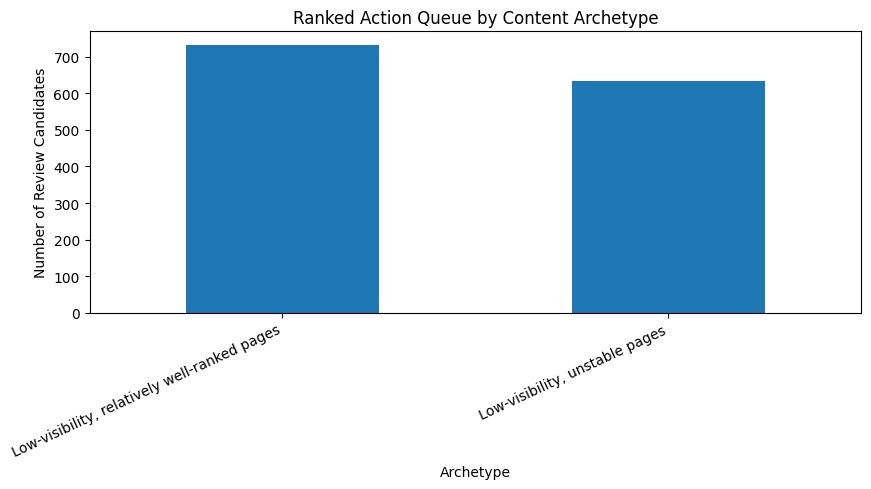

Saved figure: work/figures/ml10_action_archetypes.png


In [8]:
import os
import json
import matplotlib.pyplot as plt

# Create output directories
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --------------------------------------------------
# 1. Export ranked action queue
# --------------------------------------------------

queue_path = "work/outputs/action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print("Saved queue:", queue_path)
print("Queue rows:", len(action_queue))


# --------------------------------------------------
# 2. Export aggregate monitoring metrics
# --------------------------------------------------

metrics = {
    "week": "ML-10",
    "queue_rows": int(len(action_queue)),
    "unique_clients": int(
        action_queue["client_hash_id"].nunique()
    ),
    "baseline_opportunity_rate": float(
        (baseline_df["baseline_action_score"] > 0).mean()
    ),
    "cluster_counts": {
        str(k): int(v)
        for k, v in baseline_df["cluster"]
        .value_counts()
        .sort_index()
        .items()
    },
    "median_impressions": float(
        baseline_df["impressions"].median()
    ),
    "median_ctr": float(
        baseline_df["ctr"].median()
    ),
    "median_avg_position": float(
        baseline_df["avg_position"].median()
    )
}

metrics_path = "work/outputs/ml10_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics:", metrics_path)


# --------------------------------------------------
# 3. Create reusable cluster/action figure
# --------------------------------------------------

cluster_counts = (
    action_queue["archetype"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

cluster_counts.plot(kind="bar")

plt.title("Ranked Action Queue by Content Archetype")
plt.xlabel("Archetype")
plt.ylabel("Number of Review Candidates")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

figure_path = "work/figures/ml10_action_archetypes.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:", figure_path)

### ML-10 Self-check

- [x] Ranked action queue created from the validated baseline opportunity score.
- [x] Every queue item has a reason code.
- [x] Archetype-to-action mapping is documented.
- [x] Intended use and limitations are explicitly stated.
- [x] Human review requirements are documented.
- [x] No-go cases for automation are explicitly listed.
- [x] Monitoring signals and retrain/re-profile triggers are documented.
- [x] Cost/value thinking is reflected through review prioritization rather than invented monetary ROI.
- [x] Row-level action queue exported to `work/outputs/action_queue.csv`.
- [x] Aggregate metrics exported to `work/outputs/ml10_metrics.json`.
- [x] Reusable archetype figure exported to `work/figures/ml10_action_archetypes.png`.
- [x] The queue is treated as decision support, not as an automated content decision.
- [x] No causal claims are made from the clustering model.
- [x] No automatic rewriting, pruning, merging, canonical changes, or ranking claims are proposed.
- [x] The notebook is saved under `work/notebooks/w07_action_playbook.ipynb`.